<a href="https://colab.research.google.com/github/ChenS1313/thelook-ecommerce-analytics-pipeline/blob/ChenS1313-patch-4/thelooker_ecommerce_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1 Data Loading & Initial Exploration


### 1.1 Loading the relevant tables from **Google BigQuery**

In [ ]:
# Import relevant libraries
from google.colab import auth
from google.cloud import bigquery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Connect Google account for BigQuery access
auth.authenticate_user()

In [ ]:
# Set up the BigQuery connection and dataset name
client = bigquery.Client(project="project-69dc4deb-819d-43d1-af9")
dataset = "dbt_csinai"

# Create dataframe for each table
df_users = client.list_rows(f"{dataset}.dim_users").to_dataframe()
df_orders = client.list_rows(f"{dataset}.dim_orders").to_dataframe()
df_products = client.list_rows(f"{dataset}.dim_products").to_dataframe()
df_order_items = client.list_rows(f"{dataset}.fct_order_items").to_dataframe()


### 1.2 Checking the data structure to make sure everything loaded correctly

In [ ]:
# Verify table sizes and row counts
print(f"Users table:{df_users.shape}")
print(f"Orders table:{df_orders.shape}")
print(f"Products table:{df_products.shape}")
print(f"Order_items table:{df_order_items.shape}")

Users table:(100000, 21)
Orders table:(124931, 16)
Products table:(29120, 17)
Order_items table:(181406, 21)


In [ ]:
# Check column names and data types using .info()
datasets = {
            "Users": df_users,
            "Orders": df_orders,
            "Products": df_products,
            "Order Items": df_order_items
           }

for name,df in datasets.items():
   print(f"======== {name} Table Info ========")
   df.info()
   print("\n")

======== Users Table Info ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   user_id                 100000 non-null  object             
 1   first_name              100000 non-null  object             
 2   last_name               100000 non-null  object             
 3   age                     100000 non-null  Int64              
 4   user_age_group          80122 non-null   object             
 5   gender                  100000 non-null  object             
 6   email                   100000 non-null  object             
 7   address                 100000 non-null  object             
 8   city                    100000 non-null  object             
 9   state                   100000 non-null  object             
 10  country                 100000 non-null  object           

In [ ]:
# Inspect the data samples
df_users.head()
df_products.head()
df_order_items.head()
df_orders.head()

,order_id,user_id,status,gender,num_of_items,customer_country,created_at,shipped_at,delivered_at,returned_at,order_sales,order_cost,order_profit,returned_items_count,days_to_ship,days_to_deliver
0,958,775,Cancelled,F,1,China,2025-12-04 14:25:57+00:00,NaT,NaT,NaT,33.000000000,13.200000000,19.800000000,0,<NA>,<NA>
1,2344,1828,Cancelled,F,1,China,2025-10-27 06:40:51+00:00,NaT,NaT,NaT,53.020000000,29.430000000,23.590000000,0,<NA>,<NA>
2,2757,2177,Cancelled,F,2,United States,2025-05-30 00:14:18+00:00,NaT,NaT,NaT,144.900000000,61.910000000,82.990000000,0,<NA>,<NA>
3,7111,5707,Cancelled,F,1,Brasil,2024-09-28 08:35:28+00:00,NaT,NaT,NaT,39.410000000,23.250000000,16.160000000,0,<NA>,<NA>
4,7870,6321,Cancelled,F,1,South Korea,2022-01-13 20:29:51+00:00,NaT,NaT,NaT,128.000000000,63.620000000,64.380000000,0,<NA>,<NA>


## 2 Data Formatting

Due to default Pandas display settings when loading data from **Google BigQuery**, we apply light formatting to improve readability without changing the actual data:

- **Dates:** Standardize date formatting.

- **Numeric Columns:** Round prices and costs to 2 decimal places.
This includes casting numeric columns back to `float64` if BigQuery's `NUMERIC` type forced them into Python `object` types during import.

- **Missing Data:** Keep empty cells as Pandas `NaT` / `NaN` / `<NA>` (which match BigQuery `NULL`s).



In [ ]:
# Format all date columns across all tables
dfs_list = [df_users, df_products, df_order_items, df_orders]
for df in dfs_list:
    for col in df.columns:
        # Check if the column is of datetime type
        if df[col].dtype == 'datetime64[us, UTC]':
                df[col] = pd.to_datetime(df[col]).dt.tz_localize(None).astype('datetime64[s]')

In [ ]:
# Convert BigQuery NUMERIC columns from object back to float

# df_users
df_users['lifetime_value'] = pd.to_numeric(df_users['lifetime_value'], errors = 'coerce')
df_users['total_profit'] = pd.to_numeric(df_users['total_profit'], errors = 'coerce')

# df_products
df_products['sale_price'] = pd.to_numeric(df_products['sale_price'], errors = 'coerce')
df_products['cost'] = pd.to_numeric(df_products['cost'], errors = 'coerce')
df_products['total_sales'] = pd.to_numeric(df_products['total_sales'], errors = 'coerce')
df_products['total_profit'] = pd.to_numeric(df_products['total_profit'], errors = 'coerce')


# df_order_items
df_order_items['sale_price'] = pd.to_numeric(df_order_items['sale_price'], errors = 'coerce')
df_order_items['cost'] = pd.to_numeric(df_order_items['cost'], errors = 'coerce')
df_order_items['profit'] = pd.to_numeric(df_order_items['profit'], errors = 'coerce')

# df_orders
df_orders['order_sales'] = pd.to_numeric(df_orders['order_sales'], errors = 'coerce')
df_orders['order_cost'] = pd.to_numeric(df_orders['order_cost'], errors = 'coerce')
df_orders['order_profit'] = pd.to_numeric(df_orders['order_profit'], errors = 'coerce')


In [ ]:
# Check that all data types were successfully updated across all tables using .info()
for name,df in datasets.items():
   print(f"======== {name} Table Info ========")
   df.info()
   print("\n")

======== Users Table Info ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype        
---  ------                  --------------   -----        
 0   user_id                 100000 non-null  object       
 1   first_name              100000 non-null  object       
 2   last_name               100000 non-null  object       
 3   age                     100000 non-null  Int64        
 4   user_age_group          80122 non-null   object       
 5   gender                  100000 non-null  object       
 6   email                   100000 non-null  object       
 7   address                 100000 non-null  object       
 8   city                    100000 non-null  object       
 9   state                   100000 non-null  object       
 10  country                 100000 non-null  object       
 11  postal_code             100000 non-null  object       
 12  latitude  

## 3 Deep EDA & Vizualizations

### 3.1 Data Overview & Insights

In [ ]:
df_users.describe().T

,count,mean,min,25%,50%,75%,max,std
age,100000.0,41.03431,12.0,26.0,41.0,56.0,70.0,17.040581
latitude,100000.0,28.061178,-43.160756,25.915295,35.184997,40.695716,64.865194,22.27776
longitude,100000.0,24.372787,-158.164931,-50.611199,4.376748,116.341807,153.543292,89.873579
total_orders,100000.0,1.24931,0.0,1.0,1.0,2.0,4.0,0.989588
lifetime_value,100000.0,107.676538,0.0,16.85,61.95,151.185,1898.81,135.213529
total_profit,100000.0,55.852016,0.0,8.4375,31.01,77.82,1015.33,71.979328
first_order_date,80122,2024-06-20 02:38:56,2019-01-09 02:40:28,2023-04-16 19:09:26,2024-11-27 03:42:31,2025-12-27 14:45:40,2026-08-05 06:03:41,NaN
most_recent_order_date,80122,2025-01-10 06:16:17,2019-01-09 02:40:28,2024-03-23 07:52:48,2025-07-21 11:07:33,2026-04-06 04:36:21,2026-08-05 06:07:21,NaN
user_created_at,100000,2022-11-25 09:43:29,2019-01-02 01:14:00,2020-12-13 14:22:15,2022-11-28 11:02:30,2024-11-10 07:37:15,2026-08-05 00:55:45,NaN


#### 🔍 Insights: `df_users`
* **Age Demographics (`age`):** The average and median age are both **41 years old**, showing a balanced, normal distribution.

* **Customer Retention (`total_orders`):** Over **50% of users have placed only 1 order**. Since this data covers 2019 to 2026, it shows a real **retention challenge** - most customers remain one-time buyers.

* **User Activation (`first_order_date`):** Out of 100,000 registered users, only **79,931 have placed an order**. This leaves ~20,000 "dormant" accounts (non-buyers) that registered but never made a purchase.

* **Lifetime Value (`lifetime_value`):** LTV is **right-skewed**. Most users spend around **\$62.00** (median), but a small group of big spenders pulls the average up to **$108.28**.



In [ ]:
df_products.describe().T

,count,mean,std,min,25%,50%,75%,max
sale_price,29120.0,59.220164,65.888927,0.02,24.0,39.99,69.95,999.0
cost,29120.0,28.481889,30.624695,0.01,11.28,19.68,34.44,557.15
total_units_sold,29120.0,6.229602,2.541708,0.0,4.0,6.0,8.0,19.0
total_sales,29120.0,369.768332,476.721277,0.0,120.0,235.335,444.9275,11988.0
total_profit,29120.0,191.799505,260.601056,0.0,60.6075,117.155,224.55,7132.8
total_units_returned,29120.0,0.62706,0.791622,0.0,0.0,0.0,1.0,6.0
distribution_center_longitude,29120.0,-88.541508,11.672085,-118.25,-90.0667,-88.0431,-79.9333,-73.7834
distribution_center_latitude,29120.0,34.942039,4.431663,29.7604,30.6944,34.05,39.95,41.8369


#### 🔍 Insights: `df_products`
* **Pricing Strategy (`sale_price` vs. `cost`):** The average sale price ($59.22) is more than **double the average cost** (\$28.48), demonstrating a healthy pricing model.

* **Inventory (`total_units_sold`):**  Some products have **0 units sold**, indicating new catalog additions or inactive "deadstock" products.

* **Product Price Distribution (`sale_price`):**  The price distribution is **right-skewed** (ranging from \$0.02 up to \$999.00). Since 75% of items under $69.95, the store mostly focuses on everyday affordable items, with a few high-end luxury products on top.

In [ ]:
df_orders.describe().T

,count,mean,min,25%,50%,75%,max,std
num_of_items,124931.0,1.45205,1.0,1.0,1.0,2.0,4.0,0.807471
created_at,124931,2024-09-28 21:35:50,2019-01-09 02:40:28,2023-09-27 04:07:06,2025-03-27 22:31:04,2026-02-18 22:44:40,2026-08-05 06:07:21,NaN
shipped_at,81283,2024-09-30 11:44:35,2019-01-09 07:54:28,2023-10-02 00:07:37,2025-03-28 03:51:57,2026-02-19 09:32:15,2026-08-08 04:52:27,NaN
delivered_at,44129,2024-10-04 19:47:05,2019-01-19 09:04:24,2023-10-07 03:54:54,2025-03-28 19:29:12,2026-02-20 18:25:42,2026-08-12 16:16:03,NaN
returned_at,12561,2024-10-06 17:01:13,2019-01-20 09:07:24,2023-10-17 13:48:13,2025-03-31 01:18:57,2026-02-22 17:26:45,2026-08-14 13:24:51,NaN
order_sales,124931.0,86.188807,0.02,29.5,55.0,109.98,1723.95,93.371416
order_cost,124931.0,41.482516,0.01,14.3,27.47,53.08,800.11,43.84887
order_profit,124931.0,44.706291,0.01,14.615,27.89,56.595,923.84,50.58822
returned_items_count,124931.0,0.146161,0.0,0.0,0.0,0.0,4.0,0.507031
days_to_ship,81283.0,1.001009,0.0,0.0,1.0,2.0,2.0,0.81384


#### 🔍 Insights: `df_orders`
* **Basket Size (`num_of_items`):** The majority of orders contain only **1 item** (Median: 1, 75th percentile: 2).
* **Returns (`returned_at` & `returned_items_count`):**  While the vast majority of orders have zero returns (`returned_items_count` 75th percentile	= 0), overall **~10% of total orders** (12,483 orders) end up being returned.
* **Order Value (`order_sales`):** The Average Order Value (AOV) stands at \$86, but the distribution is right-skewed with high-value outliers reaching up to **$1,892.25**.

* **Shipping (`days_to_ship`):**  Most orders are shipped within **1 day**, with a maximum of **2 days**.
* **Delivery (`days_to_deliver`):** Final delivery to customers takes **~3 days on average** (Median: 3.0 days) with a maximum delivery time of **7 days**

In [ ]:
df_order_items.describe().T

,count,mean,min,25%,50%,75%,max,std
order_created_at,181406,2024-09-28 23:26:35,2019-01-09 02:40:28,2023-09-26 18:25:24,2025-03-29 04:30:19,2026-02-19 13:25:15,2026-08-05 06:07:21,NaN
item_created_at,181406,2024-09-29 22:27:23,2019-01-09 01:36:22,2023-09-27 18:15:30,2025-03-30 03:09:21,2026-02-20 06:08:50,2026-08-09 05:14:24,NaN
shipped_at,118181,2024-09-30 06:04:04,2019-01-09 07:54:28,2023-10-01 16:18:34,2025-03-29 19:25:03,2026-02-19 07:40:23,2026-08-08 04:52:27,NaN
delivered_at,64081,2024-10-04 12:23:47,2019-01-19 09:04:24,2023-10-09 00:19:36,2025-03-29 05:03:47,2026-02-19 21:38:18,2026-08-12 16:16:03,NaN
returned_at,18260,2024-10-05 15:37:27,2019-01-20 09:07:24,2023-10-20 16:55:11,2025-03-30 10:28:14,2026-02-19 23:20:59,2026-08-14 13:24:51,NaN
customer_age,181406.0,41.0413,12.0,26.0,41.0,56.0,70.0,17.0384
sale_price,181406.0,59.356658,0.02,24.5,39.99,69.95,999.0,66.36131
cost,181406.0,28.568252,0.01,11.39,19.77,34.54,557.15,30.907353
profit,181406.0,30.788406,0.01,11.71,20.14,35.82,594.4,36.473173


#### 🔍 Insights: `df_order_items`

* **Item Profitability (`profit`):** Profitability per item is strong at **~52% margin** (calculated as (`profit` / `sale_price`) * 100). Most items make around **\$20.24** (median), but a few high-priced premium products push the overall average up to **\$30.98**, creating a right-skewed distribution.

### 3.2 Vizualizations & Sub-Business Questions
 **Main Business Question:**
> "How can we grow company revenue and profits by focusing on the right countries and personalizing products for different customer groups?"

#### 📊 1 Market Opportunity Identification
*Which markets present high Average Order Value (AOV) despite low current order volume?*

In [ ]:
# Create country-level aggregation
country_analysis = (df_orders.groupby("customer_country").agg(AOV=("order_sales", "mean"),
                                                              order_count=("order_id", "count")).sort_values(by="AOV", ascending=False))

country_analysis = country_analysis[country_analysis["order_count"] > 1000] # Filter outliers (countries with less than 1000 orders) to prevent bias

country_analysis.reset_index(inplace=True) # Reset index

country_analysis


,customer_country,AOV,order_count
0,Japan,89.411552,3009
1,Spain,87.719530,5025
2,Germany,86.920472,5046
3,France,86.897707,5831
4,United States,86.446088,27873
5,United Kingdom,86.294959,5790
6,Brasil,86.095084,18704
7,China,85.781692,42383
8,Australia,85.548072,2744
9,South Korea,84.579436,6628


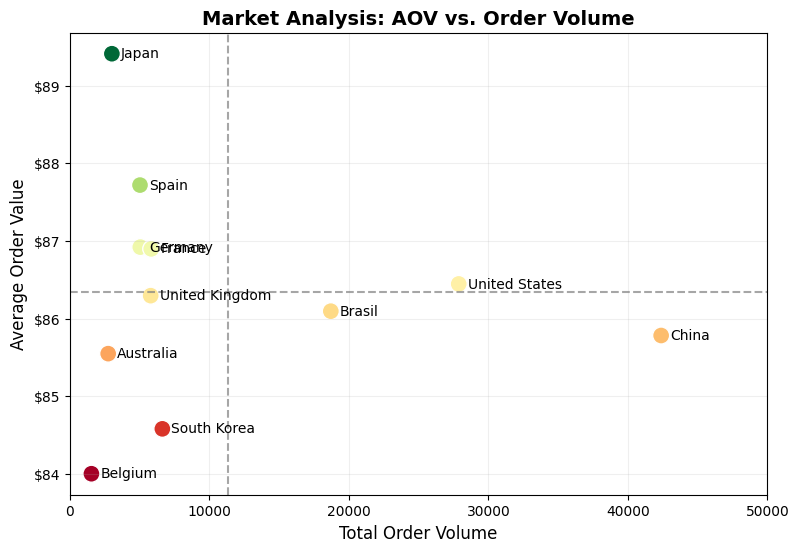

In [ ]:
# Scatter plot

plt.figure(figsize=(9, 6))
sns.scatterplot(data=country_analysis, x='order_count', y="AOV",
                        s=150,
                        hue="AOV",
                        palette="RdYlGn",
                        legend=False
                        )

# Reference lines for averages
plt.axhline(country_analysis["AOV"].mean(), color="gray", linestyle="--", alpha=0.7) # AOV average
plt.axvline(country_analysis['order_count'].mean(), color="gray", linestyle="--", alpha=0.7) # Orders average

# Add country names
for idx, row in country_analysis.iterrows():
    plt.text(
        row["order_count"] + 650, # X
        row["AOV"], # Y
        row["customer_country"], # Name
        fontsize=10,
        va="center"
        )

plt.xlim(0,50000)
plt.xlabel("Total Order Volume", fontsize=12)
plt.ylabel("Average Order Value", fontsize=12)
plt.grid(True, alpha=0.2)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')

plt.title("Market Analysis: AOV vs. Order Volume", fontsize=14, fontweight="bold")
plt.show()

#### 💡 Business Insights & Strategy

* **Retention (US, China, Brazil):** Most orders come from these countries, so it is important to focus on keeping these customers.
* **Growth (Belgium & Australia):** These countries have the highest AOV, but low order volume. We should invest in marketing campaigns there in order to scale volume.


* 🎯 Recommended Strategic Actions
  * **Core Markets (US, China, Brazil):** Run targeted loyalty rewards and win-back offers to keep existing buyers coming back.

  *  **High-AOV Markets (Belgium & Australia):** Run ads aimed at new shoppers to grow order volume while keeping AOV high.


#### 📊 2 Product-Demographic Fit Analysis
*Which product categories are bought the most across different age groups and genders?*

In [ ]:
# Create separated df for male and female
male_items = df_order_items[df_order_items["customer_gender"] == "M"]
female_items = df_order_items[df_order_items["customer_gender"] == "F"]

In [ ]:
# Create aggregated category-age-group sales for male and female
male_age_group_sales = male_items.groupby(["customer_age_group","category"])["sale_price"].sum().reset_index()
male_age_group_sales["total_males_age_group_sales"] = male_age_group_sales.groupby("customer_age_group")["sale_price"].transform("sum")
male_age_group_sales["perc_from_total"] = (male_age_group_sales["sale_price"] / male_age_group_sales["total_males_age_group_sales"]) * 100

female_age_group_sales = female_items.groupby(["customer_age_group","category"])["sale_price"].sum().reset_index()
female_age_group_sales["total_female_age_group_sales"] = female_age_group_sales.groupby("customer_age_group")["sale_price"].transform("sum")
female_age_group_sales["perc_from_total"] = (female_age_group_sales["sale_price"] / female_age_group_sales["total_female_age_group_sales"]) * 100

In [ ]:
# Create heatmap df for each gender
male_heatmap = male_age_group_sales.pivot(index="customer_age_group", columns="category", values="perc_from_total")
female_heatmap = female_age_group_sales.pivot(index="customer_age_group", columns="category", values="perc_from_total")


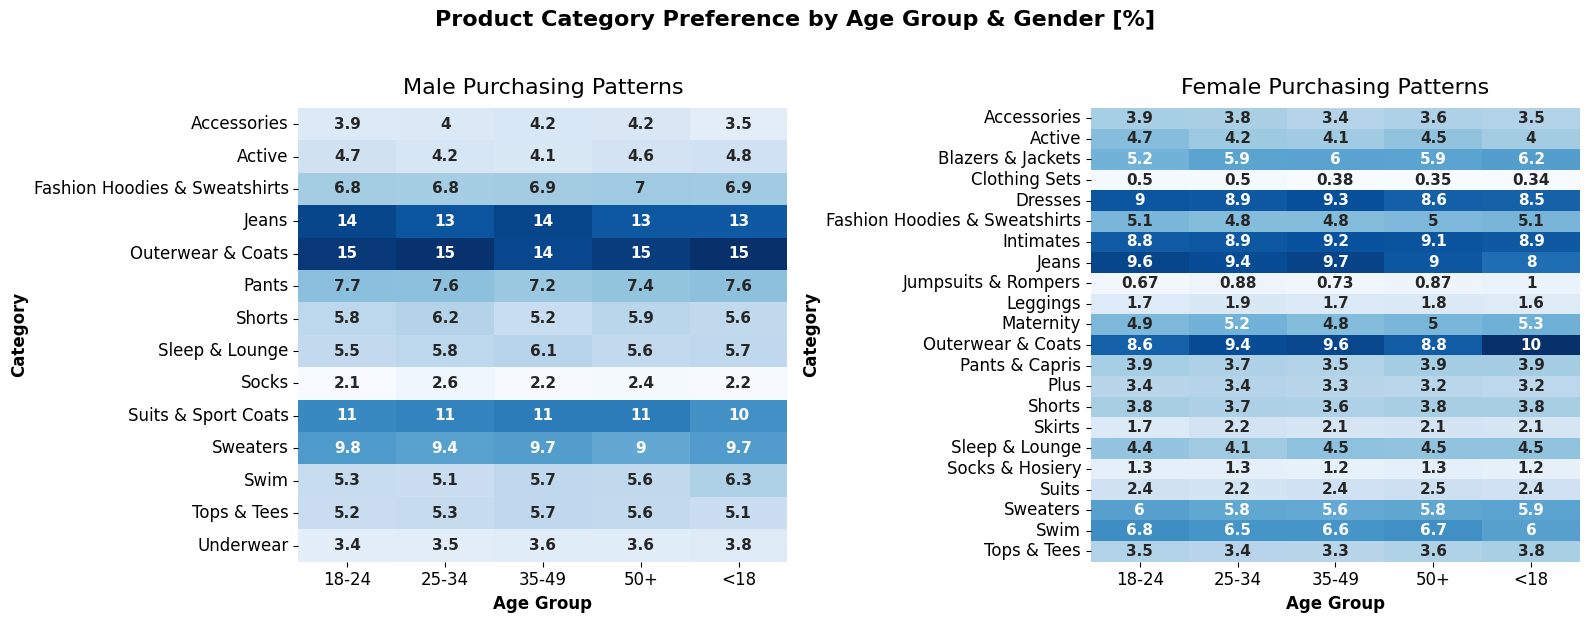

In [ ]:
# Create heatmaps

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

heatmaps_list = [male_heatmap, female_heatmap]
titles = ["Male Purchasing Patterns", "Female Purchasing Patterns"]

for i in range(len(heatmaps_list)):
    ax = axes[i]
    sns.heatmap(heatmaps_list[i].T, ax=ax,
                cmap="Blues",
                annot=True, # Shows numbers
                annot_kws={"size": 11, "weight": "bold"}, # Format numbers
                cbar=False
               )

    # Titles and Labels
    ax.set_xlabel("Age Group", fontsize=12, fontweight="bold")
    ax.set_ylabel("Category", fontsize=12, fontweight="bold")
    ax.set_title(titles[i], fontsize=16, pad=10)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

# Fig title
fig.suptitle("Product Category Preference by Age Group & Gender [%]", fontsize=16, fontweight="bold", y=1.03)

plt.tight_layout()
plt.show()

#### 💡 Business Insights & Strategy

* **Top sellers:** *Outerwear & Coats* and *Jeans* are the top sellers categories across almost all age groups. Keeping high stock and promoting them in ad campaigns is critical.

* **Youth (<18)**: *Outerwear & Coats* demand peaks in the under-18 group. Launching seasonal, targeted ad campaigns for this segment is key to capturing youth market share.

* **Targeted Gender Campaigns (Suits vs. Variety):** Men focus heavily on high-ticket items like Suits and Sweaters, while women buy across a broader range of categories like Dresses and Intimates. Ad campaigns should target these distinct buying habits.

* 🎯 Recommended Strategic Actions

  * **Personalized Ads:** Create ad campaigns based on gender—highlight *Outerwear & Suits* for male users, and feature *Dresses & Intimates* for female users.

## Exporting Mart tables to Excel for Tableau Public

Since **Tableau Public** does not support a direct connection to **Google BigQuery**, the processed and cleaned mart tables are exported from Python into a single multi-sheet Excel workbook (`Ecommerce_Data_Marts.xlsx`).



### Loading and formatting the remaining  Mart tables from BigQuery

To provide a complete 360-degree view in Tableau, the remaining two mart tables (`inventory_items` and `sessions`) are imported from BigQuery, formatted, and added to the main Excel file alongside the core tables.


In [ ]:
# Loading the remaining mart tables from BigQuery
df_inventory_items = client.list_rows(f"{dataset}.fct_inventory_items").to_dataframe()
df_sessions = client.list_rows(f"{dataset}.fct_sessions").to_dataframe()

In [ ]:
# Verify table sizes and row counts
print(f"Inventory_items table:{df_inventory_items.shape}")
print(f"Sessions table:{df_sessions.shape}")

Inventory_items table:(490234, 14)
Sessions table:(681406, 14)


In [ ]:
# Check column names and data types using .info()
new_dfs = {
                "Inventory_items": df_inventory_items,
                "Sessions": df_sessions
               }
for name,df in new_dfs.items():
   print(f"======== {name} Table Info ========")
   df.info()
   print("\n")

======== Inventory_items Table Info ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490234 entries, 0 to 490233
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   inventory_item_id       490234 non-null  object             
 1   product_id              490234 non-null  object             
 2   distribution_center_id  490234 non-null  object             
 3   department              490234 non-null  object             
 4   category                490234 non-null  object             
 5   brand                   490234 non-null  object             
 6   product_name            490234 non-null  object             
 7   product_sku             490234 non-null  object             
 8   sale_price              490234 non-null  object             
 9   cost                    490234 non-null  object             
 10  potential_profit        490234 non-null  object

In [ ]:
# Convert BigQuery NUMERIC columns from object back to float and format all date columns

# df_inventory_items
df_inventory_items['sale_price'] = pd.to_numeric(df_inventory_items['sale_price'], errors = 'coerce')
df_inventory_items['cost'] = pd.to_numeric(df_inventory_items['cost'], errors = 'coerce')
df_inventory_items['potential_profit'] = pd.to_numeric(df_inventory_items['potential_profit'], errors = 'coerce')
df_inventory_items['arrived_at'] = pd.to_datetime(df_inventory_items['arrived_at']).dt.tz_localize(None).astype('datetime64[s]')
df_inventory_items['sold_at'] = pd.to_datetime(df_inventory_items['sold_at']).dt.tz_localize(None).astype('datetime64[s]')

# df_sessions
df_sessions['session_started_at'] = pd.to_datetime(df_sessions['session_started_at']).dt.tz_localize(None).astype('datetime64[s]')
df_sessions['session_ended_at'] = pd.to_datetime(df_sessions['session_ended_at']).dt.tz_localize(None).astype('datetime64[s]')


In [ ]:
# Check that all data types were successfully updated across all tables using .info()
for name,df in new_dfs.items():
   print(f"======== {name} Table Info ========")
   df.info()
   print("\n")

======== Inventory_items Table Info ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490234 entries, 0 to 490233
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype        
---  ------                  --------------   -----        
 0   inventory_item_id       490234 non-null  object       
 1   product_id              490234 non-null  object       
 2   distribution_center_id  490234 non-null  object       
 3   department              490234 non-null  object       
 4   category                490234 non-null  object       
 5   brand                   490234 non-null  object       
 6   product_name            490234 non-null  object       
 7   product_sku             490234 non-null  object       
 8   sale_price              490234 non-null  float64      
 9   cost                    490234 non-null  float64      
 10  potential_profit        490234 non-null  float64      
 11  arrived_at              490234 non-null  datetime64[s]
 12 

### Exporting all mart tables into an Excel Workbook


In [ ]:

## Installing 'xlsxwriter' if not exists
# try:
#   import xlsxwriter
# except:
#   %pip install xlsxwriter
# import xlsxwriter

# excel_filename = 'Ecommerce_Data_Marts.xlsx'
# with pd.ExcelWriter(excel_filename, engine='xlsxwriter') as writer:
#     df_orders.to_excel(writer, sheet_name='orders', index=False)
#     df_order_items.to_excel(writer, sheet_name='order_items', index=False)
#     df_products.to_excel(writer, sheet_name='products', index=False)
#     df_users.to_excel(writer, sheet_name='users', index=False)
#     df_sessions.to_excel(writer, sheet_name='sessions', index=False)
#     df_inventory_items.to_excel(writer, sheet_name='inventory_items', index=False)
